In [1]:
#data format library
import h5py

#numpy
import numpy as np
# import pandas as pd
import numpy.ma as ma
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams['pdf.fonttype'] = 42
# %matplotlib notebook
import sys
sys.path.append('./utils/')
import matplotlib.colors as pltcolors
import os
import copy
import partitioning_methods as cl
import coarse_graining as cgm
import operator_calculations as op_calc
import delay_embedding as embed
import stats
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import time as tt
import scipy
import glob

np.random.seed(42)

In [13]:
path_to_filtered_data = '/flash/StephensU/Gautam/HMD/Results/bacteria_all/'
seeds = []
ks = []
for i in range(2000):
    s,k = np.array(np.loadtxt(path_to_filtered_data+ '/eigvals/iteration_indices.txt')[i],dtype=int)
    seeds.append(s)
    ks.append(k)

seeds = np.unique(seeds)
ks = np.unique(ks)
diff_eigs = np.zeros((len(seeds),len(ks),int(D_int.shape[0]/2)-1))

for s in seeds:
    print(s)
    for kn,k in enumerate(ks):
        f = h5py.File(path_to_filtered_data+'eigvals/diffmap_eigvals_s{}_k{}.h5'.format(s,k),'r')
        eigs_ = np.array(f['eigs_shuffle'],dtype=float)
        diff_eigs[s,kn,:] = eigs_
        f.close()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


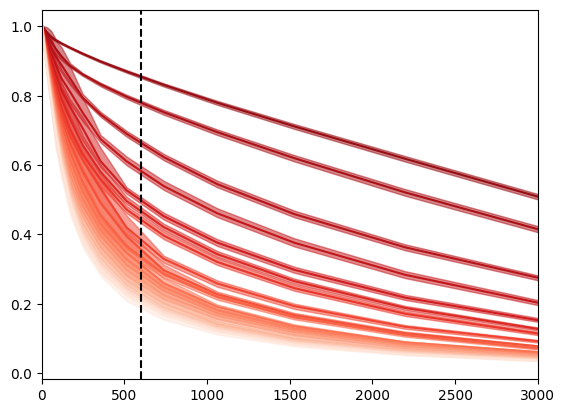

In [26]:
ms = []
cils = []
cius = []
for kn in range(len(ks)):
    cils.append(np.nanpercentile(diff_eigs[:,kn,:20],2.5,axis=0))
    cius.append(np.nanpercentile(diff_eigs[:,kn,:20],97.5,axis=0))
    ms.append(np.nanmean(diff_eigs[:,kn,:20],axis=0))
ms = np.vstack(ms)
cils = np.vstack(cils)
cius = np.vstack(cius)

colors_ = plt.cm.Reds_r(np.linspace(0.1,0.9,20))
for i in range(20):
    plt.plot(ks,ms[:,i],color = colors_[i])
    plt.fill_between(ks,cils[:,i],cius[:,i],color = colors_[i],alpha=0.5)
plt.xlim(0,3000)
plt.axvline(600,c='k',ls='--')
# plt.savefig(Fig_path + 'diff_eigvals_k.pdf')
plt.show()

In [35]:
path_to_filtered_data = '/flash/StephensU/Gautam/HMD/Results/Zebrafish/'
seeds = []
ks = []
for i in range(2000):
    s,k = np.array(np.loadtxt(path_to_filtered_data+ '/eigvals/iteration_indices.txt')[i],dtype=int)
    seeds.append(s)
    ks.append(k)

seeds = np.unique(seeds)
ks = np.unique(ks)
diff_eigs = np.zeros((len(seeds),len(ks),int(D_int.shape[0]/2)-1))

for s in seeds:
    print(s)
    for kn,k in enumerate(ks):
        f = h5py.File(path_to_filtered_data+'eigvals/diffmap_eigvals_s{}_k{}.h5'.format(s,k),'r')
        eigs_ = np.array(f['eigs_shuffle'],dtype=float)
        diff_eigs[s,kn,:] = eigs_
        f.close()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


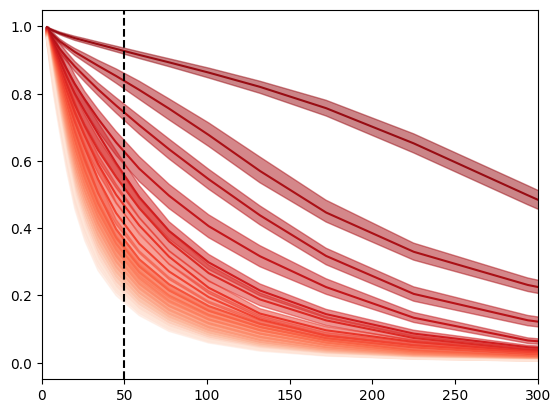

In [52]:
ms = []
cils = []
cius = []
for kn in range(len(ks)):
    cils.append(np.nanpercentile(diff_eigs[:,kn,:20],2.5,axis=0))
    cius.append(np.nanpercentile(diff_eigs[:,kn,:20],97.5,axis=0))
    ms.append(np.nanmean(diff_eigs[:,kn,:20],axis=0))
ms = np.vstack(ms)
cils = np.vstack(cils)
cius = np.vstack(cius)

colors_ = plt.cm.Reds_r(np.linspace(0.1,0.9,20))
for i in range(20):
    plt.plot(ks,ms[:,i],color = colors_[i])
    plt.fill_between(ks,cils[:,i],cius[:,i],color = colors_[i],alpha=0.5)
plt.xlim(0,300)
plt.axvline(50,c='k',ls='--')
# plt.savefig(Fig_path + 'diff_eigvals_k.pdf')
plt.show()